In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-vs-bike-classification-dataset' dataset.
Path to dataset files: /kaggle/input/car-vs-bike-classification-dataset


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Correctly identify the base path for the dataset content
dataset_base_path = os.path.join(path, 'Car-Bike-Dataset')

# Check if 'Car-Bike-Dataset' exists and list its contents
if os.path.exists(dataset_base_path):
    print(f"\nContents of the '{os.path.basename(dataset_base_path)}' directory ({dataset_base_path}):\n{os.listdir(dataset_base_path)}")
    # Further checks can be added here if needed, e.g., for 'Train' and 'Test' subdirectories
else:
    print(f"\n'Car-Bike-Dataset' directory not found at {dataset_base_path}. Please verify the dataset structure.")


Contents of the dataset directory (/kaggle/input/car-vs-bike-classification-dataset):
['Car-Bike-Dataset']

Contents of the 'Car-Bike-Dataset' directory (/kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset):
['Car', 'Bike']


In [ ]:
import os
from sklearn.model_selection import train_test_split

# Define the base path to the dataset, which was identified in the previous cell
# dataset_base_path is '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset'

# Initialize lists to store image paths and labels
all_image_paths = []
all_image_labels = []

# Iterate through each category (Car, Bike)
for category in ['Car', 'Bike']:
    category_path = os.path.join(dataset_base_path, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(category_path, img_name))
            all_image_labels.append(category)

print(f"Total images found: {len(all_image_paths)}")
print(f"Example image path: {all_image_paths[0] if all_image_paths else 'N/A'}")
print(f"Example image label: {all_image_labels[0] if all_image_labels else 'N/A'}")

Total images found: 3996
Example image path: /kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset/Car/Car (1613).jpeg
Example image label: Car


In [ ]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, random_state=42, stratify=all_image_labels
)

print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print("Dataset split successfully!")

Number of training images: 3196
Number of testing images: 800
Dataset split successfully!


### 1. Check GPU Activity
First, let's verify if a GPU is available and being used by TensorFlow.

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) found: {gpus}")
    print("TensorFlow is using GPU.")
else:
    print("No GPU found. TensorFlow will use CPU.")

GPU(s) found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow is using GPU.


### 2. Image Preprocessing and Data Preparation
Next, we'll set up the image preprocessing steps and prepare the data for training. This includes loading images, resizing them, normalizing pixel values, and encoding labels.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder

# Define image dimensions
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Function to load and preprocess a single image
def preprocess_image(image_path, label):
    img = load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img = img_to_array(img)
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img, label

# Encode labels to numerical format
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes} ({label_encoder.classes_})")

Number of classes: 2 (['Bike' 'Car'])


### 3. Create TensorFlow Datasets
We'll use `tf.data.Dataset` for efficient data loading and preprocessing during training.

In [ ]:
import tensorflow as tf
import numpy as np # Needed for tf.py_function input conversion

# A helper Python function to perform image loading and error handling
def _parse_image_and_label_py(image_path_tensor, label_tensor):
    # Convert TensorFlow tensors to Python native types
    image_path = image_path_tensor.numpy().decode('utf-8')
    label = label_tensor.numpy()

    try:
        img_bytes = tf.io.read_file(image_path)
        # Use decode_image for broader format support and specify channels=3
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)

        # Crucial check: Ensure the decoded image has a valid rank and is 3-dimensional.
        # If rank is unknown or not 3, something is wrong with the image.
        if img.shape.rank is None or img.shape.rank != 3:
            raise ValueError(f"Decoded image '{image_path}' has invalid rank: {img.shape.rank}")

        img = tf.image.convert_image_dtype(img, tf.float32) # Scale to [0, 1] and convert type
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        # Explicitly set the static shape for consistency
        img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])

        return img, label, np.array(True, dtype=np.bool_) # Return image, label, and a 'valid' flag

    except (tf.errors.InvalidArgumentError, ValueError) as e:
        # Catch errors related to image decoding or invalid shapes
        print(f"Skipping problematic image: '{image_path}' due to error: {e}")
        # Return dummy tensors and a 'false' flag for invalid images
        return np.zeros((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32), \
               np.array(0, dtype=np.int32), \
               np.array(False, dtype=np.bool_)

# The TensorFlow graph-compatible function that wraps the Python logic
def parse_image_and_label_tf(image_path, label):
    image, label, is_valid = tf.py_function(
        _parse_image_and_label_py,
        inp=[image_path, label],
        Tout=[tf.float32, tf.int32, tf.bool]
    )
    # Set static shapes for output tensors expected by the graph
    image.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
    label.set_shape([]) # Scalar label
    is_valid.set_shape([]) # Scalar boolean

    return image, label, is_valid

# Create TensorFlow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded))
train_dataset = train_dataset.map(parse_image_and_label_tf, num_parallel_calls=tf.data.AUTOTUNE)
# Filter out any images that failed to decode or had invalid shapes
train_dataset = train_dataset.filter(lambda image, label, is_valid: is_valid)
# Now remove the 'is_valid' flag as it's no longer needed in the final dataset elements
train_dataset = train_dataset.map(lambda image, label, is_valid: (image, label))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded))
test_dataset = test_dataset.map(parse_image_and_label_tf, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.filter(lambda image, label, is_valid: is_valid)
test_dataset = test_dataset.map(lambda image, label, is_valid: (image, label))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created with robust image loading and filtering.")

TensorFlow datasets created with robust image loading and filtering.


### 4. Build ResNet Model
We will use a pre-trained ResNet50 model from `tf.keras.applications` and add custom classification layers on top.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the pre-trained ResNet50 model without the top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling layer
x = Dense(256, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with softmax for classification

# Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
print("ResNet model built and compiled.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

ResNet model built and compiled.


### 5. Train the Model
Now, let's train the ResNet model using the prepared datasets.

In [ ]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset
)

print("Model training complete.")

Epoch 1/10
    100/Unknown 37s 243ms/step - accuracy: 0.6220 - loss: 0.7080

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 339ms/step - accuracy: 0.7118 - loss: 0.5585 - val_accuracy: 0.7337 - val_loss: 0.4922
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 213ms/step - accuracy: 0.7972 - loss: 0.4381 - val_accuracy: 0.8163 - val_loss: 0.3941
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 203ms/step - accuracy: 0.8223 - loss: 0.3904 - val_accuracy: 0.8562 - val_loss: 0.3434
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 211ms/step - accuracy: 0.8273 - loss: 0.3829 - val_accuracy: 0.8700 - val_loss: 0.3231
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.8529 - loss: 0.3377 - val_accuracy: 0.8650 - val_loss: 0.3212
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step - accuracy: 0.8373 - loss: 0.3479 - val_accuracy: 0.8850 - val_loss: 0.2996
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.8558 - loss: 0.3262 - val_accuracy: 0.8850 - val_loss: 0.2910
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.8648 - loss: 0.3101 - val

### 6. Summarize Training Results
Let's evaluate the model on the test set and print the final accuracy and loss.

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.8850 - loss: 0.2968

Test Loss: 0.2968
Test Accuracy: 0.8850


### 7. Display Training Plots
Finally, we'll visualize the training and validation accuracy and loss over the epochs to understand the model's learning process.

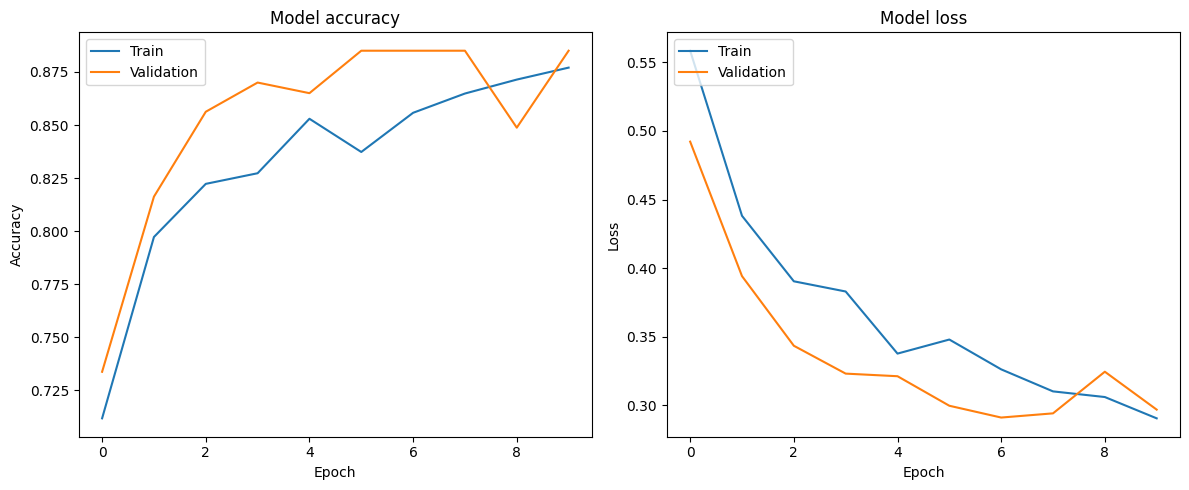

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()